# Kernel Density Estimation (KDE)

## Real-World Scenario: Non-parametric Profiling of Single-Cell Flow Cytometry

In whole-cell modeling, a single population of cells rarely behaves homogeneously. When we read out a protein marker by **flow cytometry** (e.g., GFP reporter fluorescence, CD4, CD8), the measurements can be strongly **multimodal** — a subset of cells is in the "off" state, another in the "on" state, and sometimes intermediate subpopulations exist. A Gaussian fit would hide this structure entirely.

**Kernel density estimation (KDE)** is the non-parametric answer: we place a little "bump" (a *kernel*) on every data point and average them to recover an empirical density. No cluster count to specify, no mixture weights to fit — just bandwidth.

In this notebook we follow PML §16.3 and cover:

1. **Density kernels** (§16.3.1) — Gaussian, boxcar, Epanechnikov, tri-cube
2. **The Parzen-window estimator** (§16.3.2) — KDE in 1D on a bimodal GFP reporter
3. **Bandwidth selection** (§16.3.3) — Scott's rule vs. leave-one-out cross-validation
4. **KDE → KNN classification** (§16.3.4) — classifying T-cell subtypes from surface markers
5. **Nadaraya–Watson kernel regression** (§16.3.5) — dose-response curves with predictive variance
6. **Locally weighted regression (LOESS)** (§16.3.5.3)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'


## Key Formulas from PML Chapter 16.3

**Parzen–window / kernel density estimator** (Eq. 16.33):

$$p(x \mid \mathcal{D}) = \frac{1}{N}\sum_{n=1}^{N} K_h(x - x_n)$$

where $K_h(u) = \frac{1}{h} K(u/h)$ is a kernel with bandwidth $h$, satisfying $\int K(u)\,du = 1$ and $K(-u) = K(u)$.

**Gaussian RBF kernel in $D$ dimensions** (Eq. 16.30):

$$K_h(\mathbf{x}) = \frac{1}{h^D (2\pi)^{D/2}}\exp\!\left(-\frac{1}{2h^2}\|\mathbf{x}\|^2\right)$$

**Rule-of-thumb bandwidth** (§16.3.3), for 1D Gaussian data:

$$h = \left(\frac{4}{3N}\right)^{1/5}\hat\sigma, \qquad \hat\sigma = 1.4826\cdot \mathrm{MAD}(x)$$

**KDE-derived class posterior → KNN** (Eq. 16.35):

$$p(y = c \mid \mathbf{x}, \mathcal{D}) = \frac{1}{K}\sum_{n \in \mathcal{N}_K(\mathbf{x})} \mathbb{1}(y_n = c)$$

**Nadaraya–Watson regression estimator** (Eq. 16.39–16.40):

$$\mathbb{E}[y \mid \mathbf{x}, \mathcal{D}] = \sum_{n=1}^{N} w_n(\mathbf{x})\,y_n, \quad w_n(\mathbf{x}) = \frac{K_h(\mathbf{x} - \mathbf{x}_n)}{\sum_{n'} K_h(\mathbf{x} - \mathbf{x}_{n'})}$$

**Predictive variance** (Eq. 16.45):

$$\mathbb{V}[y \mid \mathbf{x}, \mathcal{D}] = \sigma^2 + \sum_{n=1}^{N} w_n(\mathbf{x})\,y_n^2 - \mu(\mathbf{x})^2$$

## 1. Density kernels (§16.3.1)

A **density kernel** $K : \mathbb{R} \to \mathbb{R}_+$ is any symmetric function that integrates to 1. Four popular choices are listed in Table 16.1:

| Name | $K(u)$ | Compact | Smooth |
|---|---|---|---|
| Gaussian | $(2\pi)^{-1/2} e^{-u^2/2}$ | no | yes |
| Boxcar | $\tfrac{1}{2}\mathbb{1}(\lvert u\rvert\le 1)$ | yes | no |
| Epanechnikov | $\tfrac{3}{4}(1-u^2)\,\mathbb{1}(\lvert u\rvert\le 1)$ | yes | yes (not at boundary) |
| Tri-cube | $\tfrac{70}{81}(1-\lvert u\rvert^3)^3\,\mathbb{1}(\lvert u\rvert\le 1)$ | yes | yes (everywhere) |

Let's implement and visualize all four (reproducing Figure 16.8).

  Gaussian      : integral = 0.9973
  Boxcar        : integral = 0.9999
  Epanechnikov  : integral = 1.0000
  Tri-cube      : integral = 1.0000


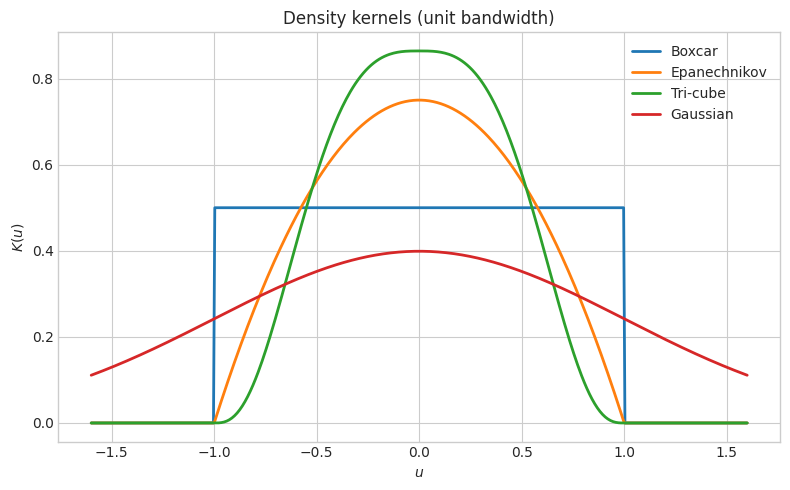

In [2]:
def gaussian_kernel(u):
    return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

def boxcar_kernel(u):
    return 0.5 * (np.abs(u) <= 1).astype(float)

def epanechnikov_kernel(u):
    return 0.75 * (1 - u**2) * (np.abs(u) <= 1)

def tricube_kernel(u):
    return (70 / 81) * (1 - np.abs(u)**3)**3 * (np.abs(u) <= 1)

# Sanity check: each kernel should integrate to 1
u_fine = np.linspace(-3, 3, 10001)
for name, k_fn in [('Gaussian', gaussian_kernel),
                   ('Boxcar', boxcar_kernel),
                   ('Epanechnikov', epanechnikov_kernel),
                   ('Tri-cube', tricube_kernel)]:
    integral = np.trapezoid(k_fn(u_fine), u_fine)
    print(f"  {name:14s}: integral = {integral:.4f}")

u = np.linspace(-1.6, 1.6, 500)
fig, ax = plt.subplots(figsize=(8, 5))
for name, k_fn, c in [('Boxcar', boxcar_kernel, 'C0'),
                      ('Epanechnikov', epanechnikov_kernel, 'C1'),
                      ('Tri-cube', tricube_kernel, 'C2'),
                      ('Gaussian', gaussian_kernel, 'C3')]:
    ax.plot(u, k_fn(u), lw=2, label=name, color=c)
ax.set_xlabel(r'$u$')
ax.set_ylabel(r'$K(u)$')
ax.set_title('Density kernels (unit bandwidth)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 2. The Parzen-window estimator (§16.3.2)

We simulate a single-cell GFP reporter experiment: 200 cells from a population in which ~70% are in the "reporter on" state (high GFP), and ~30% are in the "reporter off" state (low GFP). The true density is a bimodal Gaussian mixture, but we pretend we don't know that and estimate it non-parametrically with

$$\hat p(x) = \frac{1}{N h}\sum_{n=1}^{N} K\!\left(\frac{x - x_n}{h}\right)$$

We compare a **boxcar** kernel (piecewise-constant histogram-like estimate) vs. a **Gaussian** kernel, each at two bandwidths $h \in \{0.2,\, 0.8\}$. This reproduces the structure of Figure 16.9.

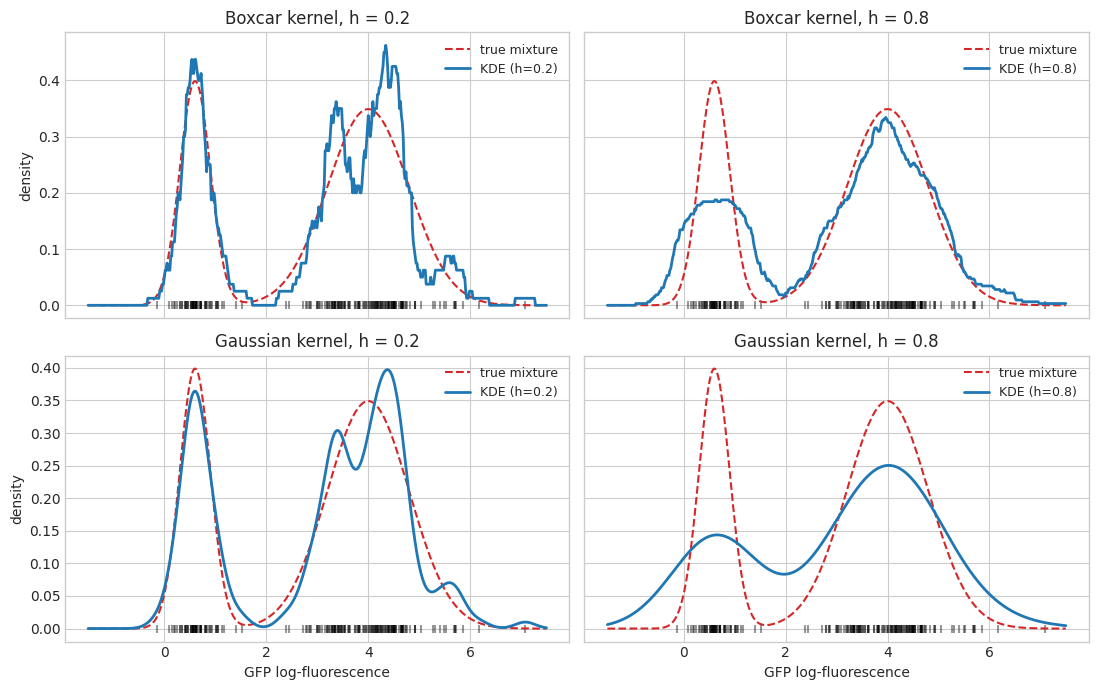

In [3]:
# Simulate single-cell GFP log-fluorescence
n_cells = 200
is_on = np.random.rand(n_cells) < 0.7
gfp = np.where(
    is_on,
    np.random.normal(4.0, 0.8, n_cells),   # "on" state
    np.random.normal(0.6, 0.3, n_cells),   # "off" state
)

def kde_1d(x_eval, data, h, kernel_fn):
    """Parzen-window estimate: p(x) = (1/(N*h)) * sum_n K((x - x_n)/h)."""
    u = (x_eval[:, None] - data[None, :]) / h
    return kernel_fn(u).mean(axis=1) / h

# Ground-truth mixture density for reference
def true_density(x):
    return (
        0.7 * np.exp(-0.5 * ((x - 4.0) / 0.8)**2) / (0.8 * np.sqrt(2*np.pi))
        + 0.3 * np.exp(-0.5 * ((x - 0.6) / 0.3)**2) / (0.3 * np.sqrt(2*np.pi))
    )

x_eval = np.linspace(-1.5, 7.5, 500)
p_true = true_density(x_eval)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey='row')
for i, h in enumerate([0.2, 0.8]):
    for j, (name, k_fn) in enumerate([('Boxcar', boxcar_kernel),
                                       ('Gaussian', gaussian_kernel)]):
        ax = axes[j, i]
        p_hat = kde_1d(x_eval, gfp, h, k_fn)
        ax.plot(x_eval, p_true, ls='--', color='C3', lw=1.5, label='true mixture')
        ax.plot(x_eval, p_hat, lw=2, color='C0', label=f'KDE (h={h})')
        ax.scatter(gfp, np.zeros_like(gfp), marker='|', color='k', alpha=0.4, s=40)
        ax.set_title(f'{name} kernel, h = {h}')
        if j == 1:
            ax.set_xlabel('GFP log-fluorescence')
        if i == 0:
            ax.set_ylabel('density')
        ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
print(x_eval[:, None].shape)
print(gfp[None, :].shape)
(x_eval[:, None] - gfp[None, :]).shape

(500, 1)
(1, 200)


(500, 200)

Both kernels recover the bimodal structure once the bandwidth is reasonable, but:

- **Small $h$ (0.2)** → low bias, high variance. The boxcar version is a jagged rug; the Gaussian version is spiky.
- **Large $h$ (0.8)** → smoother but over-smoothed, bleeds density across the gap between the two modes.
- The **Gaussian** kernel produces a differentiable estimate; the **boxcar** kernel produces a piecewise-constant "moving histogram".

## 3. Bandwidth selection (§16.3.3)

Bandwidth is the **only hyperparameter** of KDE and it determines the bias–variance trade-off. Two common strategies:

**(a) Rule-of-thumb (Silverman / Scott).** Minimizing asymptotic mean integrated squared error under a Gaussian reference yields

$$h^\star = \left(\frac{4}{3N}\right)^{1/5}\hat\sigma$$

The scale $\hat\sigma$ is usually estimated robustly as $1.4826 \cdot \mathrm{MAD}(x)$.

**(b) Leave-one-out cross-validation.** Maximize

$$\mathrm{CV}(h) = \frac{1}{N}\sum_{i=1}^{N}\log\hat p_{-i}(x_i;\,h)$$

where $\hat p_{-i}$ is the KDE fit **excluding** $x_i$. This is almost free for a Gaussian kernel: just zero the diagonal of the full pairwise kernel matrix.

Scott's rule:    h = 0.557
LOO-CV optimal:  h = 0.252


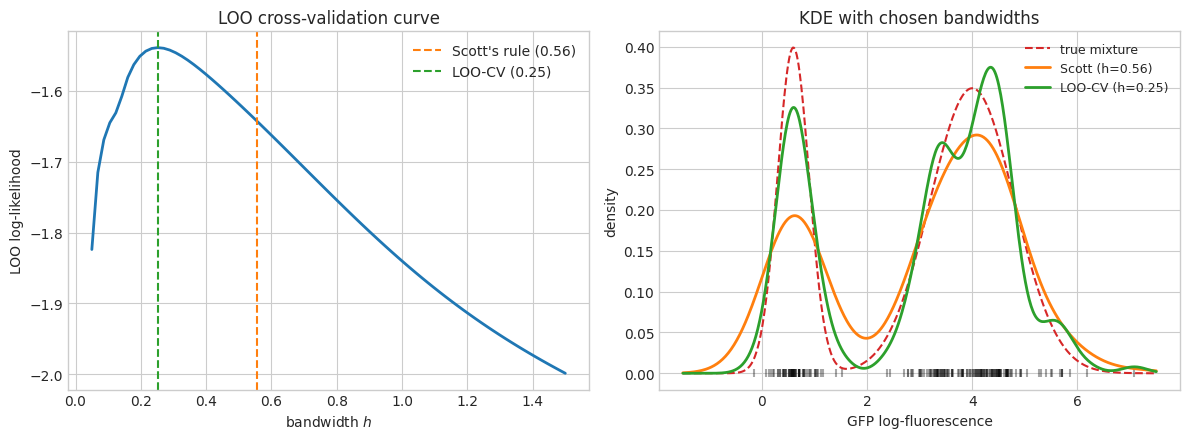

In [4]:
def scott_bandwidth(data):
    N = len(data)
    sigma_std = np.std(data, ddof=1)
    mad = np.median(np.abs(data - np.median(data)))
    sigma_robust = 1.4826 * mad
    sigma_eff = min(sigma_std, sigma_robust) if sigma_robust > 0 else sigma_std
    return (4 / (3 * N))**(1/5) * sigma_eff

def loo_log_lik(data, h):
    """Leave-one-out log-likelihood for a Gaussian-kernel KDE."""
    N = len(data)
    u = (data[:, None] - data[None, :]) / h
    K = gaussian_kernel(u)
    np.fill_diagonal(K, 0.0)
    p_loo = K.sum(axis=1) / ((N - 1) * h)
    return np.mean(np.log(np.maximum(p_loo, 1e-12)))

h_scott = scott_bandwidth(gfp)
hs = np.linspace(0.05, 1.5, 80)
ll = np.array([loo_log_lik(gfp, h) for h in hs])
h_cv = hs[np.argmax(ll)]

print(f"Scott's rule:    h = {h_scott:.3f}")
print(f"LOO-CV optimal:  h = {h_cv:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(hs, ll, lw=2, color='C0')
axes[0].axvline(h_scott, ls='--', color='C1', label=f"Scott's rule ({h_scott:.2f})")
axes[0].axvline(h_cv, ls='--', color='C2', label=f'LOO-CV ({h_cv:.2f})')
axes[0].set_xlabel('bandwidth $h$')
axes[0].set_ylabel('LOO log-likelihood')
axes[0].set_title('LOO cross-validation curve')
axes[0].legend()

axes[1].plot(x_eval, p_true, ls='--', color='C3', lw=1.5, label='true mixture')
axes[1].plot(x_eval, kde_1d(x_eval, gfp, h_scott, gaussian_kernel),
             lw=2, color='C1', label=f"Scott (h={h_scott:.2f})")
axes[1].plot(x_eval, kde_1d(x_eval, gfp, h_cv, gaussian_kernel),
             lw=2, color='C2', label=f'LOO-CV (h={h_cv:.2f})')
axes[1].scatter(gfp, np.zeros_like(gfp), marker='|', color='k', alpha=0.35, s=40)
axes[1].set_xlabel('GFP log-fluorescence')
axes[1].set_ylabel('density')
axes[1].set_title('KDE with chosen bandwidths')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Scott's rule assumes a single Gaussian-like shape, so it tends to **oversmooth** genuinely multimodal data like our bimodal GFP. LOO-CV adapts to the data and typically picks a smaller bandwidth that preserves both modes.

## 4. From KDE to KNN classification (§16.3.4)

PML §16.3.4 derives KNN classification as a special case of a generative classifier whose class-conditional densities are KDEs with an **adaptive** (balloon) bandwidth: instead of fixing $h$, we grow a ball around the query until it contains exactly $K$ training points. The class posterior collapses to

$$p(y=c \mid \mathbf{x}, \mathcal{D}) = \frac{1}{K}\sum_{n \in \mathcal{N}_K(\mathbf{x})} \mathbb{1}(y_n = c)$$

which is ordinary KNN voting. We apply this to classify three T-cell subtypes by their **CD4** and **CD8** surface-marker log-intensities (a caricature of a real flow-cytometry gating problem).

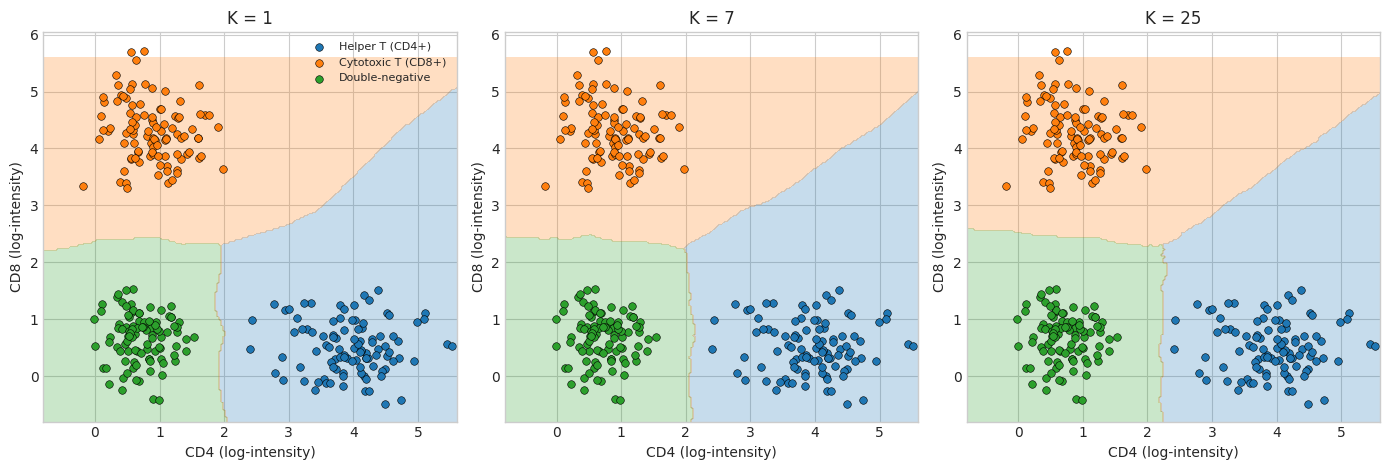

In [5]:
# Simulate three T-cell subpopulations in (CD4, CD8) space
n_per = 100
labels = ['Helper T (CD4+)', 'Cytotoxic T (CD8+)', 'Double-negative']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

means = [np.array([4.0, 0.5]),
         np.array([0.8, 4.2]),
         np.array([0.6, 0.7])]
covs  = [np.diag([0.35, 0.20]),
         np.diag([0.20, 0.35]),
         np.diag([0.15, 0.15])]

X_parts, y_parts = [], []
for c, (mu, Sigma) in enumerate(zip(means, covs)):
    X_parts.append(np.random.multivariate_normal(mu, Sigma, n_per))
    y_parts.append(np.full(n_per, c))
X_train = np.vstack(X_parts)
y_train = np.concatenate(y_parts)

def knn_predict(X_test, X_train, y_train, K):
    """Majority-vote KNN (balloon-KDE classifier, Eq. 16.35)."""
    d2 = ((X_test[:, None, :] - X_train[None, :, :])**2).sum(-1)
    idx = np.argsort(d2, axis=1)[:, :K]
    neigh = y_train[idx]
    n_classes = int(y_train.max()) + 1
    return np.array([np.bincount(row, minlength=n_classes).argmax() for row in neigh])

grid_x, grid_y = np.meshgrid(np.linspace(-0.8, 5.6, 200),
                             np.linspace(-0.8, 5.6, 200))
grid = np.column_stack([grid_x.ravel(), grid_y.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for ax, K in zip(axes, [1, 7, 25]):
    pred = knn_predict(grid, X_train, y_train, K).reshape(grid_x.shape)
    cmap = mpl.colors.ListedColormap(colors)
    ax.contourf(grid_x, grid_y, pred, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=colors, alpha=0.25)
    for c, name in enumerate(labels):
        m = y_train == c
        ax.scatter(X_train[m, 0], X_train[m, 1], color=colors[c],
                   edgecolor='k', linewidth=0.4, s=30, label=name)
    ax.set_xlabel('CD4 (log-intensity)')
    ax.set_ylabel('CD8 (log-intensity)')
    ax.set_title(f'K = {K}')
    if K == 1:
        ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

Varying $K$ reproduces the same bias–variance trade-off we saw for the bandwidth $h$:

- **$K = 1$** — highly flexible, noisy boundaries (high variance).
- **$K = 7$** — balanced.
- **$K = 25$** — smoother but starts to miss the double-negative pocket near the origin.

## 5. Nadaraya–Watson kernel regression (§16.3.5)

KDE also gives us a non-parametric **regression** estimator. For a joint KDE model
$\hat p(x, y) = \frac{1}{N}\sum_n K_h(x - x_n)K_h(y - y_n)$, plugging into the definition of conditional expectation and integrating out $y$ gives

$$\mu(x) = \mathbb{E}[y \mid x, \mathcal{D}] = \sum_{n=1}^{N}w_n(x)\,y_n, \qquad w_n(x) = \frac{K_h(x - x_n)}{\sum_{n'} K_h(x - x_{n'})}$$

The same derivation gives a **predictive variance** (Eq. 16.45):

$$\mathbb{V}[y \mid x, \mathcal{D}] = \sigma^2 + \sum_n w_n(x)\,y_n^2 - \mu(x)^2$$

where $\sigma^2$ is the variance of the $y$-kernel. We apply this to a **drug dose–response** experiment: for each of 80 log-concentrations we measure percent cell viability, and we want a smooth predictive curve.

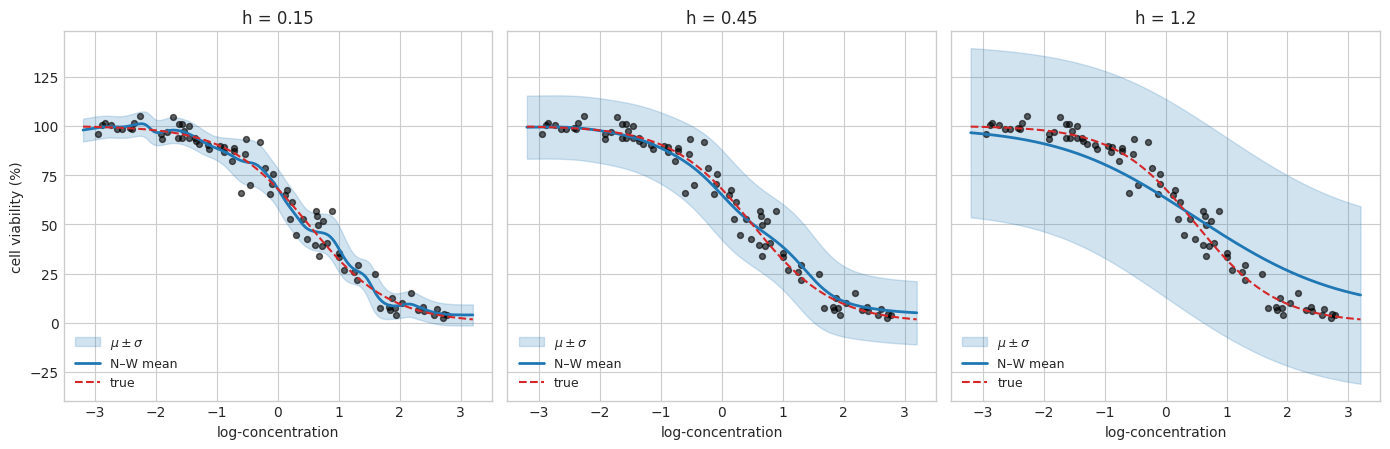

In [6]:
# Simulate a sigmoidal dose-response with heteroscedastic noise
n = 80
log_dose = np.sort(np.random.uniform(-3, 3, n))

def true_curve(x):
    return 100 / (1 + np.exp(1.5 * (x - 0.5)))

noise_scale = 3 + 6 * (np.abs(log_dose - 0.5) < 1.2)  # noisier in the transition
viability = true_curve(log_dose) + np.random.normal(0, noise_scale)

def nadaraya_watson(x_eval, x_train, y_train, h):
    """Return (mean, variance) at x_eval using a Gaussian kernel."""
    u = (x_eval[:, None] - x_train[None, :]) / h
    K = gaussian_kernel(u) / h
    W = K / K.sum(axis=1, keepdims=True)
    mu = W @ y_train
    # Eq. 16.45:  V = sigma^2 + sum_n w_n y_n^2 - mu^2
    sigma2_y = np.var(y_train)  # approximate kernel-y variance
    var = sigma2_y * (h**2) + W @ (y_train**2) - mu**2
    return mu, np.maximum(var, 0.0)

x_plot = np.linspace(-3.2, 3.2, 400)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
for ax, h in zip(axes, [0.15, 0.45, 1.2]):
    mu, var = nadaraya_watson(x_plot, log_dose, viability, h)
    std = np.sqrt(var)
    ax.fill_between(x_plot, mu - std, mu + std, color='C0', alpha=0.2,
                    label=r'$\mu \pm \sigma$')
    ax.plot(x_plot, mu, lw=2, color='C0', label='N–W mean')
    ax.plot(x_plot, true_curve(x_plot), ls='--', color='C3', lw=1.5, label='true')
    ax.scatter(log_dose, viability, color='k', s=18, alpha=0.6)
    ax.set_xlabel('log-concentration')
    ax.set_title(f'h = {h}')
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('cell viability (%)')
plt.tight_layout()
plt.show()

- At the **smallest bandwidth**, the mean curve interpolates every datapoint — and the predictive variance band blows up in data-sparse regions.
- At **moderate bandwidth** ($h \approx 0.45$), the fit tracks the sigmoid nicely while the variance band correctly widens in the transition zone where the true curve is steep.
- At the **largest bandwidth**, the fit flattens and systematically mis-estimates the plateaus (bias).

## 6. Locally weighted linear regression / LOESS (§16.3.5.3)

Nadaraya–Watson is a **locally constant** estimator: at each query point it averages $y_n$ with kernel weights. A natural generalization is to fit a **local linear model** instead:

$$\mu(x) = \arg\min_{a,b}\sum_{n=1}^{N}K_h(x - x_n)\,(y_n - a - b\,x_n)^2$$

This is **LOESS** (locally weighted scatterplot smoothing). Because each local fit has access to a slope, LOESS avoids the "boundary bias" that plagues Nadaraya–Watson at the edges of the domain, where nearby points are all on one side.

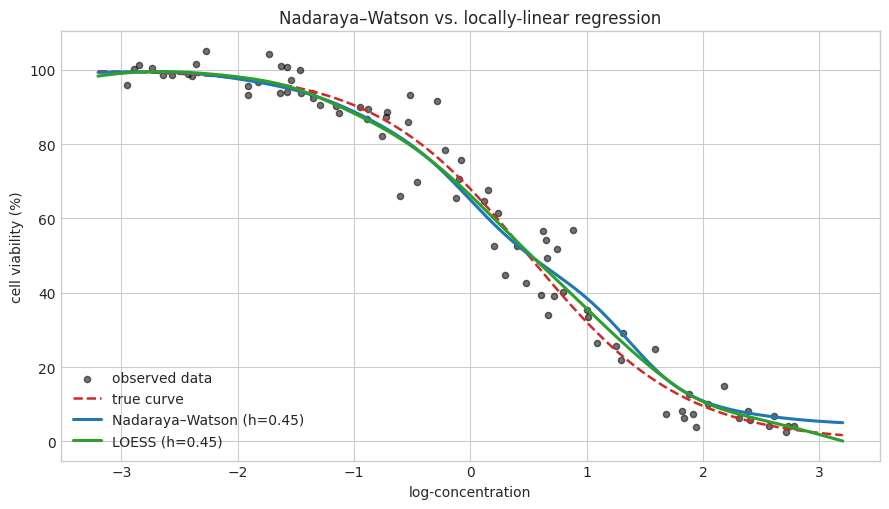

In [7]:
def loess(x_eval, x_train, y_train, h):
    """Locally weighted linear regression with Gaussian weights."""
    preds = np.empty_like(x_eval, dtype=float)
    for i, x0 in enumerate(x_eval):
        w = gaussian_kernel((x_train - x0) / h)
        Xm = np.column_stack([np.ones_like(x_train), x_train])
        # Weighted normal equations: (X^T W X) beta = X^T W y
        WX = Xm * w[:, None]
        A = Xm.T @ WX + 1e-8 * np.eye(2)
        b = Xm.T @ (w * y_train)
        beta = np.linalg.solve(A, b)
        preds[i] = beta[0] + beta[1] * x0
    return preds

h = 0.45
mu_nw, _ = nadaraya_watson(x_plot, log_dose, viability, h)
mu_loess = loess(x_plot, log_dose, viability, h)

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.scatter(log_dose, viability, color='k', s=20, alpha=0.55, label='observed data')
ax.plot(x_plot, true_curve(x_plot), ls='--', color='C3', lw=1.8, label='true curve')
ax.plot(x_plot, mu_nw, lw=2.2, color='C0', label=f'Nadaraya–Watson (h={h})')
ax.plot(x_plot, mu_loess, lw=2.2, color='C2', label=f'LOESS (h={h})')
ax.set_xlabel('log-concentration')
ax.set_ylabel('cell viability (%)')
ax.set_title('Nadaraya–Watson vs. locally-linear regression')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Notice how the Nadaraya–Watson curve **bends away from the extremes** near the left and right edges of the data: at those points all neighbours sit on one side, so the weighted average pulls inward. LOESS corrects this by locally fitting a line, whose slope captures the trend and yields a much better boundary fit — exactly why LOESS is the go-to tool for adding trend lines to scatter plots.

## Summary

| Concept | PML equation | What it gives us |
|---|---|---|
| Density kernel $K(u)$ | Table 16.1 | A localized, symmetric, normalized bump |
| Parzen–window KDE | Eq. 16.33 | Non-parametric density $\hat p(x)$ |
| Bandwidth rule-of-thumb | §16.3.3 | Quick default $h \propto N^{-1/5}$ |
| LOO cross-validation | §16.3.3 | Data-driven $h$, better for multimodal data |
| Balloon KDE ⇒ KNN | Eq. 16.35 | KNN classification as a generative model |
| Nadaraya–Watson | Eq. 16.39 | Local-constant non-parametric regression |
| N–W variance | Eq. 16.45 | Predictive uncertainty bands |
| LOESS | Eq. 16.47 | Local-linear regression, removes boundary bias |

**Takeaways for single-cell / whole-cell modeling:**

- KDE is the natural first reach when a phenotype (GFP level, cytokine abundance, cell size) may be multimodal — the bandwidth is the **only** knob.
- LOO-CV should be preferred to Scott's rule whenever the data is clearly not single-Gaussian.
- The equivalence KDE ↔ KNN explains why KNN works at all: it **is** a generative classifier under an adaptive-bandwidth KDE.
- For dose-response and other scalar regression readouts, Nadaraya–Watson gives a quick non-parametric estimate **with** an uncertainty band; LOESS is the better default at boundaries.

In Chapter 17, these ideas are generalized further by replacing the fixed kernel with a **learned** covariance function, giving Gaussian Process regression.